## Albatross Movement Analysis Extension
In order to extend and deepen the analysis of albatross movement, this notebook adapts a previously presented methodology used for the White Storks to Albatrosses.

This notebook contains:
- estimation of Levy flight parameters and validation of them using stabby package
- turning angle analysis for Albatrosses

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd
from src.simulators import *
from src.estimators import *

plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
PALETTE = sns.color_palette("tab10")
sns.set_style("darkgrid")

## 1. Data loading and additional transformation

In [5]:
DATA_PATH = "data/galapagos_albatrosses/clean_df_albatrosses_steps.csv"
df_albatrosses = pd.read_csv(DATA_PATH)
print(f"\nClean dataset : {len(df_albatrosses):,} rows, {df_albatrosses['individual_id'].nunique()} individuals")


Clean dataset : 15,538 rows, 28 individuals


In [6]:
df_albatrosses

,event-id,timestamp,lon,lat,eobs:battery-voltage,eobs:fix-battery-voltage,eobs:horizontal-accuracy-estimate,eobs:key-bin-checksum,eobs:speed-accuracy-estimate,eobs:start-timestamp,...,study-name,utm-easting,utm-northing,utm-zone,study-timezone,study-local-timestamp,dt_sec,step_m,speed_ms,turn_angle
0,28209304,2008-06-23 18:00:55.998000+00:00,-89.620939,-1.389553,3737,3482,6.66,3494220518,3.35,2008-06-23 18:00:00.000,...,Galapagos Albatrosses,208338.043949,9.846250e+06,16S,Galapagos Time,2008-06-23 12:00:55.998,5447.000,7.144987,0.001312,147.064131
1,28209305,2008-06-23 19:30:44.001000+00:00,-89.620973,-1.389570,3725,3525,5.38,2856251359,3.67,2008-06-23 19:30:01.000,...,Galapagos Albatrosses,208334.248626,9.846249e+06,16S,Galapagos Time,2008-06-23 13:30:44.001,5388.003,4.216159,0.000783,25.963614
2,28209306,2008-06-23 21:00:20.001000+00:00,-89.621014,-1.389570,3732,3564,5.89,2703843193,3.37,2008-06-23 21:00:00.000,...,Galapagos Albatrosses,208329.604931,9.846249e+06,16S,Galapagos Time,2008-06-23 15:00:20.001,5376.000,4.635465,0.000862,115.573962
3,28209307,2008-06-23 22:30:49.999000+00:00,-89.620991,-1.389521,3732,3525,4.10,971271019,2.87,2008-06-23 22:29:59.000,...,Galapagos Albatrosses,208332.226962,9.846254e+06,16S,Galapagos Time,2008-06-23 16:30:49.999,5429.998,6.077311,0.001119,91.821471
4,28209308,2008-06-24 00:00:36+00:00,-89.620894,-1.389571,3730,3505,7.42,1021047728,3.62,2008-06-24 00:00:01.000,...,Galapagos Albatrosses,208343.001588,9.846249e+06,16S,Galapagos Time,2008-06-23 18:00:36.000,5386.001,12.107183,0.002248,124.086252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15533,28254405,2008-07-24 09:01:50.001000+00:00,-81.083074,-1.276792,3762,3535,1.79,1854301547,0.33,2008-07-24 09:00:01.000,...,Galapagos Albatrosses,490758.231375,9.858876e+06,17S,Galapagos Time,2008-07-24 03:01:50.001,5466.003,61.063460,0.011172,-103.650245
15534,28254406,2008-07-24 10:30:32.999000+00:00,-81.083119,-1.276804,3769,3559,3.84,3731683025,0.99,2008-07-24 10:29:59.000,...,Galapagos Albatrosses,490753.169653,9.858874e+06,17S,Galapagos Time,2008-07-24 04:30:32.999,5322.998,5.254548,0.000987,-88.731829
15535,28254409,2008-07-24 16:31:19.998000+00:00,-80.944132,-1.815987,3759,3535,7.17,2032259719,0.96,2008-07-24 16:30:00.000,...,Galapagos Albatrosses,506213.575845,9.799278e+06,17S,Galapagos Time,2008-07-24 10:31:19.998,21646.999,61912.765990,2.860109,-113.919783
15536,28254410,2008-07-24 18:00:55.998000+00:00,-80.931767,-1.806202,3759,3540,3.33,2663970444,2.91,2008-07-24 18:00:00.000,...,Galapagos Albatrosses,507588.834735,9.800360e+06,17S,Galapagos Time,2008-07-24 12:00:55.998,5376.000,1752.746171,0.326032,-158.531465


**Filtering step lengths**

When a tracking device records a very small step length, it means the stork is sitting completely still (resting, sleeping, or nesting). Because animals spend a lot of time resting, tracking data will contain a massive spikes near zeros. As was suggested during seminar we will filter out these observations.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_albatrosses['timestamp'] = pd.to_datetime(df_albatrosses['timestamp'], format='ISO8601')
df_albatrosses = df_albatrosses.sort_values(by=['individual_id', 'timestamp']).reset_index(drop=True)

initial_count = len(df_albatrosses)
print(f"Total raw rows loaded: {initial_count:,}")

# recalculate Time Differences (dt_sec) between consecutive fixes per bird
df_albatrosses['dt_sec'] = df_albatrosses.groupby('individual_id')['timestamp'].diff().dt.total_seconds()

# check for extreme values
raw_min_speed = df_albatrosses['speed_ms'].min()
raw_max_speed = df_albatrosses['speed_ms'].max()
raw_min_step = df_albatrosses['step_m'].min()
raw_max_step = df_albatrosses['step_m'].max()
print(f"Minimum Speed: {raw_min_speed} m/s")
print(f"Maximum Speed: {raw_max_speed} m/s")
print(f"Minimum Step: {raw_min_step} m")
print(f"Maximum Step: {raw_max_step} m")


MIN_SPEED = 0.0005  # m/s 
MAX_SPEED = 30.0  # m/s

# Data for Albatrosses are sparser than for White Storks, so interval for steps is 1.5h - 2h
MIN_TIME_GAP = 5400.0 # seconds
MAX_TIME_GAP = 7200.0 # seconds

df_clean_steps = df_albatrosses.dropna(subset=['step_m', 'speed_ms', 'turn_angle', 'dt_sec']).copy()
print(df_clean_steps['dt_sec'].max())
print(df_clean_steps['dt_sec'].min())
df_clean_steps = df_clean_steps[
    (df_clean_steps['speed_ms'] >= MIN_SPEED) & 
    (df_clean_steps['speed_ms'] <= MAX_SPEED)
]

# Apply the double-sided time filter
df_clean_steps = df_clean_steps[
    (df_clean_steps['dt_sec'] >= MIN_TIME_GAP) &
    (df_clean_steps['dt_sec'] <= MAX_TIME_GAP)
]

final_count = len(df_clean_steps)
removed_count = initial_count - final_count

print(f"rows filtered out: {removed_count:,} ({removed_count/initial_count:.2%})")
print(f"rows retained {final_count:,} ({final_count/initial_count:.2%})")

print(f"cleaned speed range: [{df_clean_steps['speed_ms'].min()} to {df_clean_steps['speed_ms'].max()}] m/s")
print(f"cleaned step range [{df_clean_steps['step_m'].min():.2f} to {df_clean_steps['step_m'].max():.2f}] meters")

print("=" * 80)

Total raw rows loaded: 15,538
Minimum Speed: 4.631616868918739e-06 m/s
Maximum Speed: 16.89414756685142 m/s
Minimum Step: 0.0248625147207389 m
Maximum Step: 475981.7086392537 m
804651.999
5271.999
rows filtered out: 8,883 (57.17%)
rows retained 6,655 (42.83%)
cleaned speed range: [0.0005000150877536 to 16.89414756685142] m/s
cleaned step range [2.70 to 91735.22] meters


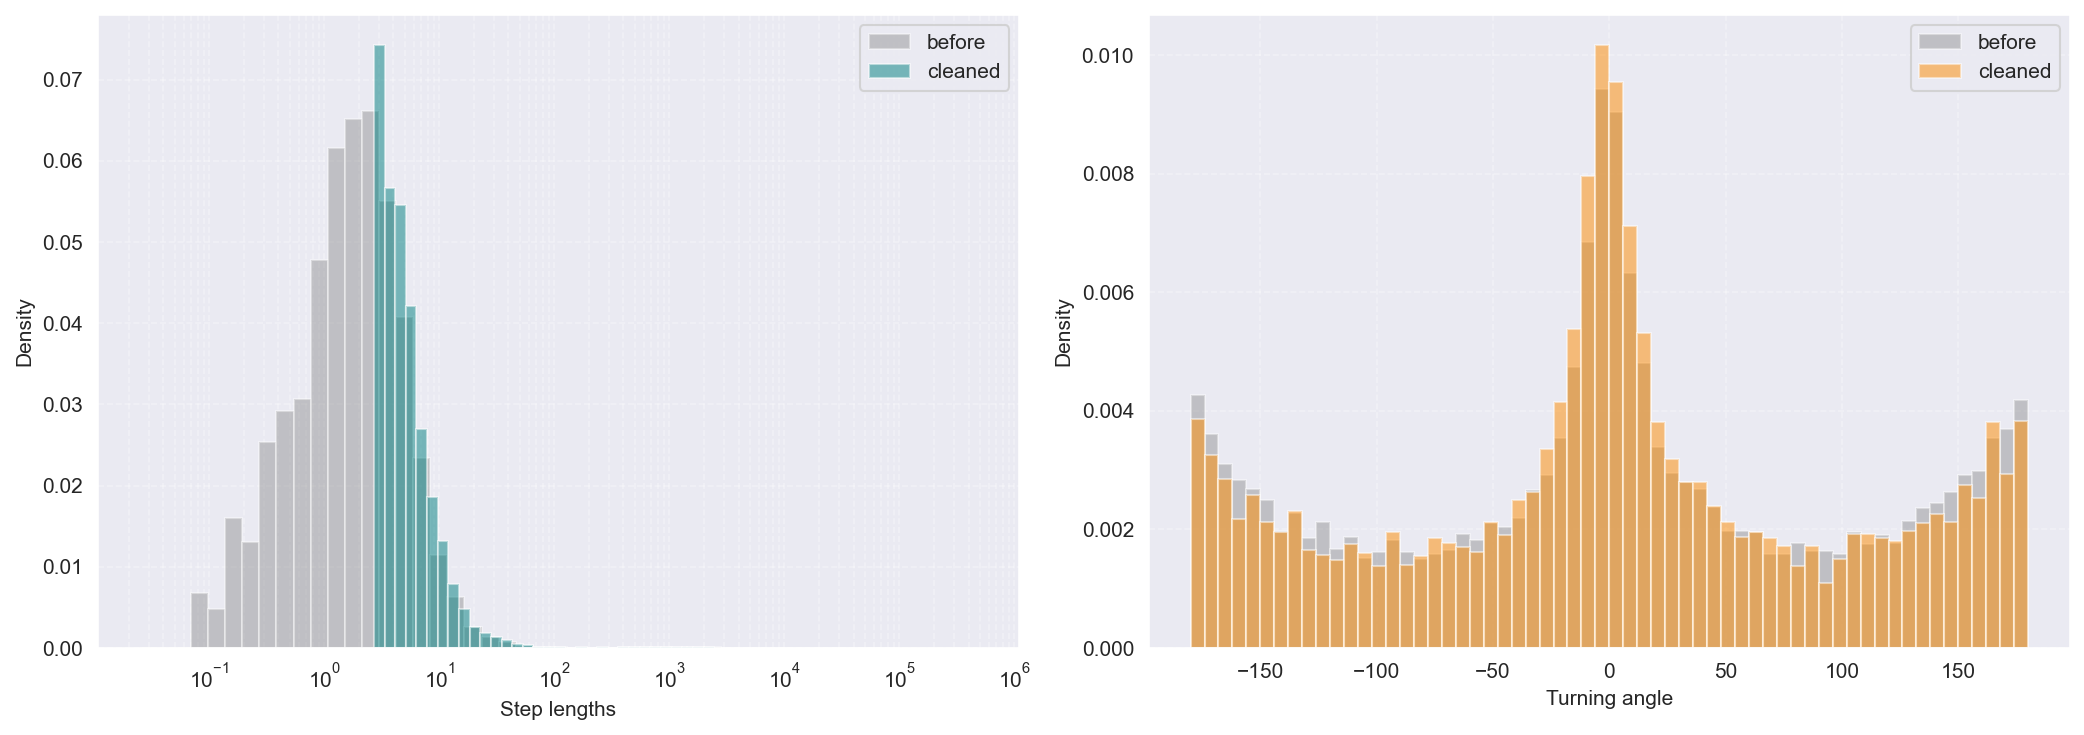

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins_raw = np.logspace(np.log10(df_albatrosses['step_m'].min()), np.log10(df_albatrosses['step_m'].max()), 50)
bins_clean = np.logspace(np.log10(df_clean_steps['step_m'].min()), np.log10(df_clean_steps['step_m'].max()), 50)

axes[0].hist(df_albatrosses['step_m'].dropna(), bins=bins_raw, alpha=0.4, color='gray', label='before', density=True)
axes[0].hist(df_clean_steps['step_m'], bins=bins_clean, alpha=0.5, color='teal', label='cleaned', density=True)
axes[0].set_xscale('log')
axes[0].set_xlabel('Step lengths')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, which="both", ls="--", alpha=0.3)

axes[1].hist(df_albatrosses['turn_angle'].dropna(), bins=60, alpha=0.4, color='gray', label='before', density=True)
axes[1].hist(df_clean_steps['turn_angle'], bins=60, alpha=0.5, color='darkorange', label='cleaned', density=True)
axes[1].set_xlabel('Turning angle')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, ls="--", alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Estimation and validation with stabpy

Similarly to White Storks, we will compare estimated parameters obtained in [previous notebook](02_Levy_Flight_Fitting_Mateusz.ipynb) using our implementations on data before transformation with those resulting from [stabpy](https://github.com/juliakonczal/StabPy?tab=readme-ov-file) package on modified data. Then, we will use this package to further assert goodness of fit with statistical tests on top of preliminary validation performed in previous notebook.

Global parameters estimated previously for the pooled `step_m` values.
<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>alpha</th>
      <th>beta</th>
      <th>sigma</th>
      <th>mu</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>McCulloch</th>
      <td>0.7209</td>
      <td>1.0000</td>
      <td>1880.2298</td>
      <td>539.5996</td>
    </tr>
    <tr>
      <th>Koutrouvelis</th>
      <td>0.4626</td>
      <td>0.7473</td>
      <td>7.1606</td>
      <td>0.7569</td>
    </tr>
  </tbody>
</table>
</div>

We also performed estimation for individual birds. Here, we present those with the most observations.

In [9]:
per_bird_df = pd.read_csv("data/galapagos_albatrosses/per_bird_est.csv")
top10 = (
    per_bird_df["n"]
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)
top_df = per_bird_df.loc[top10]
top_df

,n,alpha_mcc,beta_mcc,sigma_mcc,mu_mcc,alpha_kou,beta_kou,sigma_kou,mu_kou
3,2304.0,0.685924,1.0,1213.121302,21.004007,0.522914,0.886560,5.708716,-0.160591
13,1472.0,1.089539,1.0,1973.200104,51.613348,0.489247,0.580396,7.016594,1.668170
11,1470.0,0.962504,1.0,4412.641840,2352.567373,0.345628,0.851812,22.897189,0.587495
1,1305.0,0.587158,1.0,877.927247,18.227199,0.650210,1.000000,6.712145,-3.346610
14,1299.0,1.110989,1.0,5751.230531,2431.000751,0.315536,0.685137,28.811480,0.959664
9,1091.0,0.857948,1.0,3329.175164,1329.122342,0.347172,0.815381,15.897276,1.318096
12,970.0,0.965738,1.0,1339.237919,957.911990,0.361981,0.600237,14.771682,1.458155
5,907.0,0.721848,1.0,2113.873929,1039.951614,0.470697,0.521357,6.396829,1.691476
10,752.0,0.952255,1.0,3635.751520,1895.453405,0.254455,0.543234,15.955519,1.490399
2,750.0,0.628435,1.0,1586.009739,244.344363,0.424640,0.495138,4.782644,1.785301


Now, we will use stabpy implementations of these estimators to compare our results.
First, we will consider pooled observations.

In [11]:
import stabpy

step_vals = df_clean_steps["step_m"].values

#mcculloch
alpha_q, sigma_q, beta_q, mu_q = stabpy.stabcull(step_vals)
print(f"Quantile estimates: α={alpha_q:.3f}, β={beta_q:.3f}, sigma={sigma_q:.3f}, mu={mu_q:.3f}")

# Estimate parameters (regression method - more accurate) - Koutrouvelis
alpha_r, sigma_r, beta_r, mu_r = stabpy.stabreg(step_vals)
print(f"Regression estimates: α={alpha_r:.3f}, β={beta_r:.3f}, sigma={sigma_r:.3f}, mu={mu_r:.3f}")

Quantile estimates: α=0.811, β=1.000, sigma=1315.992, mu=-5971.356
Regression estimates: α=0.168, β=0.432, sigma=43.699, mu=6.388


We again observe a significant discrepancy between our custom global parameter estimates and those generated by `stabpy`. As extensively discussed in the previous notebook, these deviations are expected and stem from the simplified nature of our initial implementations compared to `stabpy`'s complete algorithmic frameworks:

* **McCulloch:** As established previously, our baseline approach lacks the full skewness and scale normalizations (the empirical `psi3` and `psi4` adjustments). In this dataset, this limitation causes severe distortions, most notably the drastic shift in the $\mu$ parameter (from 539.60 down to -5971.36) and an inflated $\sigma$ estimate.
* **Koutrouvelis:** The difference in regression strategies is clearly visible here. `stabpy`'s dynamic, iterative frequency grid provides a much more robust fit for this heavy-tailed data compared to our single-pass static grid, leading to significantly adjusted estimates across the board (e.g., $\alpha$ dropping from 0.463 to 0.168).

Relying on these previous findings, we will exclusively use the fully implemented iterative Koutrouvelis method via `stabpy` for our final analysis due to its superior accuracy and robustness. 

Moving forward, the focus shifts to observation data for individual birds. We will extract `stabpy` parameters for each specific trajectory and validate these estimates by performing goodness-of-fit tests for the Koutrouvelis method.

In [13]:
from tqdm import tqdm
import stabpy

# modified goodness of fit test copied from stabpy source with added tqdm and prints for tests
def custom_stabtest(x, ilp=500):
    """
        Interpretation:
        - Small p-values (< 0.05) suggest the data is not from a stable distribution
        - Large p-values indicate the stable distribution fits the data well
        - Different tests have different sensitivities to various departures from
        the null hypothesis
    """
    x = np.asarray(x, dtype=float).reshape(-1)
    n = x.size
    
    # Estimate parameters using the robust regression method
    alpha, sigma, beta, mu = stabpy.stabreg(x)
    print(f"\n Stabtest fitted params Alpha={alpha:.4f}, Sigma={sigma:.4f}, Beta={beta:.4f}, Mu={mu:.4f}")
    
    # Initialize result array
    y = np.zeros(14, dtype=float)
    
    # Compute sorted empirical CDF values
    z = np.sort(stabpy.stabcdf(x, alpha, sigma, beta, mu))
    
    # Kolmogorov-Smirnov statistic: maximum distance between empirical and theoretical CDF
    kp = np.max(np.arange(1, n+1)/n - z)  # maximum positive deviation
    km = np.max(z - np.arange(0, n)/n)    # maximum negative deviation
    Dp = np.max([kp, km]) * (np.sqrt(n) + 0.12 + 0.11/np.sqrt(n))
    
    # Kuiper statistic: sum of maximum positive and negative deviations
    Vp = (kp + km) * (np.sqrt(n) + 0.155 + 0.24/np.sqrt(n))
    
    # Cramér-von Mises statistic: integrated squared distance
    W2 = np.sum((z - (np.arange(1, 2*n, 2)/(2*n)))**2) + 1/(12*n)
    
    # Watson statistic: Cramér-von Mises with location correction
    U2 = W2 - n * (np.mean(z) - 0.5)**2
    
    # Modified statistics with finite-sample corrections
    W2p = (W2 - 0.4/n + 0.6/n**2) * (1 + 1/n)
    U2p = (U2 - 0.1/n + 0.1/n**2) * (1 + 0.8/n)
    
    # Anderson-Darling statistic: weighted squared distance (more weight in tails)
    A2p = - (1/n) * np.dot(np.arange(1, 2*n, 2), 
                            (np.log(z) + np.log(1 - z[::-1]))) - n
    
    # print(f" KS={Dp:.4f}, Kuiper={Vp:.4f}, CvM={W2p:.4f}, Watson={U2p:.4f}, AD={A2p:.4f}")
    # print(f"Running Monte Carlo...")
    
    # Generate random trajectories for Monte Carlo validation
    proba = sigma * stabpy.stabrnd(alpha, beta, n, ilp) + mu
    probat = np.zeros((ilp, 5), dtype=float)
    
    for i in tqdm(range(ilp)):
        # Estimate parameters for simulated sample
        a_i, s_i, b_i, m_i = stabpy.stabreg(proba[:, i])
        z_i = np.sort(stabpy.stabcdf(proba[:, i], a_i, s_i, b_i, m_i))
        
        # Compute test statistics for simulated sample
        kp = np.max(np.arange(1, n+1)/n - z_i)
        km = np.max(z_i - np.arange(0, n)/n)
        probat[i, 0] = np.max([kp, km]) * (np.sqrt(n) + 0.12 + 0.11/np.sqrt(n))
        probat[i, 1] = (kp + km) * (np.sqrt(n) + 0.155 + 0.24/np.sqrt(n))
        
        W2 = np.sum((z_i - (np.arange(1, 2*n, 2)/(2*n)))**2) + 1/(12*n)
        U2 = W2 - n * (np.mean(z_i) - 0.5)**2
        probat[i, 2] = (W2 - 0.4/n + 0.6/n**2) * (1 + 1/n)
        probat[i, 3] = (U2 - 0.1/n + 0.1/n**2) * (1 + 0.8/n)
        probat[i, 4] = - (1/n) * np.dot(np.arange(1, 2*n, 2), 
                                         (np.log(z_i) + np.log(1 - z_i[::-1]))) - n
    
    # Compile results
    y[0:4] = [alpha, sigma, beta, mu]
    pt = np.array([Dp, Vp, W2p, U2p, A2p], dtype=float)
    y[4:9] = pt
    
    # Compute p-values: proportion of simulated statistics exceeding observed
    pvals = np.array([(probat[:, j] > pt[j]).sum()/ilp for j in range(5)], dtype=float)
    y[9:14] = pvals
    
    return y

Similarly to White Storks we will estimate parameters and perform tests for all birds with at least 500 observations. This dataset is much smaller than White Storks and individual bird has no more than 2500 observations, thus we do not need to sample observations.


In [22]:
import os
import io
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.stats import levy_stable
import stabpy
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

os.makedirs("stable_plots/passed", exist_ok=True)
os.makedirs("stable_plots/failed", exist_ok=True)

bird_counts = df_clean_steps.groupby("individual_id").size()
filtered_birds = bird_counts[bird_counts >= 500].sort_values(ascending=False).index.tolist()

print("=" * 85)
print(f"{len(filtered_birds)} birds with at least 500 points")
print("=" * 85)

all_birds_database = {}
MC_ITERATIONS = 500 

for rank, bird_id in enumerate(filtered_birds):

    df_bird_full = df_clean_steps[df_clean_steps["individual_id"] == bird_id].sort_values("timestamp")
    s_b = df_bird_full["step_m"].values
    total_obs = len(s_b)
    
    try:
        aq, sq, bq, mq = stabpy.stabcull(s_b)
    except Exception:
        aq, sq, bq, mq = 0, 0, 0, 0

    try:
        ar, sr, br, mr = stabpy.stabreg(s_b)
    except Exception:
        ar, sr, br, mr = None, None, None, None
        
    if ar is None:
        print(f"'{bird_id}' failed regression")
        continue  
    print("Estimated for full data", ar, sr, br, mr)
        

    test_res = custom_stabtest(s_b, ilp=MC_ITERATIONS)

        
    pvals = test_res[9:14]  # captured empirical p-values
    passing_tests_count = np.sum(pvals >= 0.05)
    
    safe_bird_name = str(bird_id).replace(" ", "_").replace("(", "").replace(")", "").replace("/", "_")
    
    if passing_tests_count >= 3:
        status_folder = "passed"
        print(f"'{bird_id}' passed validation ({passing_tests_count}/5 tests accepted).")
    else:
        status_folder = "failed"
        print(f"'{bird_id}' failed validation ({passing_tests_count}/5 tests accepted).")
        
    # Save the FULL DATASET parameters to your database
    all_birds_database[bird_id] = {
        "Total Observations (n)": total_obs,
        "Passing Tests Count": passing_tests_count,
        "Status": "Passed" if passing_tests_count >= 3 else "Failed",
        "alpha_cull": aq, "beta_cull": bq, "sigma_cull": sq, "mu_cull": mq,
        "alpha_reg": ar, "beta_reg": br, "sigma_reg": sr, "mu_reg": mr,
        "p_KS": pvals[0], "p_Kuiper": pvals[1], "p_CvM": pvals[2], "p_Watson": pvals[3], "p_AD": pvals[4],
        "stat_KS": test_res[4], "stat_Kuiper": test_res[5], "stat_CvM": test_res[6], "stat_Watson": test_res[7], "stat_AD": test_res[8]
    }

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f"{bird_id}", fontweight="bold", fontsize=14)
    
    ax1 = axes[0, 0]
    bins = np.logspace(np.log10(max(1, s_b.min())), np.log10(s_b.max()), 50)
    
    # Plotting the FULL empirical dataset
    ax1.hist(s_b, bins=bins, density=True, alpha=0.5, color="royalblue", edgecolor="white", label="Empirical steps (Full)")
    
    levy_stable.parameterization = 'S0'
    x_grid = np.logspace(np.log10(max(1, s_b.min())), np.log10(s_b.max()), 300)
    
    # Using the FULL dataset parameters for the theoretical PDF
    pdf_fitted = levy_stable.pdf(x_grid, ar, br, loc=mr, scale=sr)
    
    ax1.plot(x_grid, pdf_fitted, color="darkorange", lw=2.5, label=f"Fitted PDF ($\\alpha$={ar:.2f})")
    ax1.set_xscale("log")
    ax1.set_xlabel("Step lengths (meters)")
    ax1.set_ylabel("Probability density")
    ax1.set_title('Histogram with PDF')
    ax1.grid(True, which="both", ls="--", alpha=0.3)
    ax1.legend()

    # --- (The rest of your plotting code remains the same, but use s_b_full where applicable) ---
    ax2 = axes[0, 1]
    s_b_sorted = np.sort(s_b)
    theoretical_cdf = stabpy.stabcdf(s_b_sorted, ar, sr, br, mr)
    empirical_cdf = np.arange(1, len(s_b)+1) / (len(s_b)+1)
    sample_indices = np.linspace(0, len(s_b)-1, min(1000, len(s_b))).astype(int)
    
    ax2.scatter(theoretical_cdf[sample_indices], empirical_cdf[sample_indices], 
                color="crimson", alpha=0.5, s=8, label="empirical quantiles", zorder=3)
    ax2.plot([0, 1], [0, 1], 'k--', label='theoretical fit', lw=1.5, zorder=2)
    ax2.set_xlabel('Theoretical quantiles')
    ax2.set_ylabel('Empirical quantiles')
    ax2.set_title('Q-Q Plot')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    ax3 = axes[1, 0]
    ax3.plot(s_b[:500], color="teal", linewidth=1.0, alpha=0.8)
    ax3.set_xlabel('($t$)')
    ax3.set_ylabel('Step (m)')
    ax3.set_title('First 500 steps')
    ax3.grid(True, alpha=0.3)
    
    ax4 = axes[1, 1]
    params_quant = [aq, bq]
    params_reg = [ar, br]
    x_pos = np.arange(2)
    width = 0.35
    ax4.bar(x_pos - width/2, params_quant, width, label='Quantile (stabcull)', color="orange", alpha=0.8)
    ax4.bar(x_pos + width/2, params_reg, width, label='Regression (stabreg)', color="purple", alpha=0.8)
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(['$\\alpha$', '$\\beta$'])
    ax4.set_title('Parameter estimation comparison')
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    dashboard_destination = os.path.join("stable_plots", status_folder, f"dashboard_{safe_bird_name}.png")
    plt.savefig(dashboard_destination, dpi=150, bbox_inches='tight')
    plt.close()


per_bird_df = pd.DataFrame(all_birds_database).T

column_ordering = [
    "Total Observations (n)", "Passing Tests Count", "Status",
    "alpha_cull", "beta_cull", "sigma_cull", "mu_cull",
    "alpha_reg", "beta_reg", "sigma_reg", "mu_reg",
    "p_KS", "p_Kuiper", "p_CvM", "p_Watson", "p_AD",
    "stat_KS", "stat_Kuiper", "stat_CvM", "stat_Watson", "stat_AD"
]
per_bird_df = per_bird_df.reindex(columns=column_ordering)


display(per_bird_df.round(4))

5 birds with at least 500 points
Estimated for full data 0.33473526808195553 19.275478374233398 1.0 -7699.149187973489

 Stabtest fitted params Alpha=0.3347, Sigma=19.2755, Beta=1.0000, Mu=-7699.1492


100%|██████████| 500/500 [01:09<00:00,  7.17it/s]


'unbanded-159' failed validation (0/5 tests accepted).
Estimated for full data 0.17475303756103694 1633.3774051754403 -1.0 328005.0553448123

 Stabtest fitted params Alpha=0.1748, Sigma=1633.3774, Beta=-1.0000, Mu=328005.0553


100%|██████████| 500/500 [00:41<00:00, 12.08it/s]


'1163-1163' passed validation (5/5 tests accepted).
Estimated for full data 0.18482994261606778 1633.8832462552484 1.0 15524.33876205328

 Stabtest fitted params Alpha=0.1848, Sigma=1633.8832, Beta=1.0000, Mu=15524.3388


...

100%|██████████| 500/500 [00:45<00:00, 10.87it/s]


'3275-30662' failed validation (1/5 tests accepted).
Estimated for full data 0.08983426853578083 348.01443336456833 1.0 -1013.7012002211762

 Stabtest fitted params Alpha=0.0898, Sigma=348.0144, Beta=1.0000, Mu=-1013.7012


100%|██████████| 500/500 [00:47<00:00, 10.53it/s]


'unbanded-153' passed validation (5/5 tests accepted).


,Total Observations (n),Passing Tests Count,Status,alpha_cull,beta_cull,sigma_cull,mu_cull,alpha_reg,beta_reg,sigma_reg,mu_reg,p_KS,p_Kuiper,p_CvM,p_Watson,p_AD,stat_KS,stat_Kuiper,stat_CvM,stat_Watson,stat_AD
unbanded-159,990,0,Failed,0.856976,1.0,1194.404779,-9203.136004,0.334735,1.0,19.275478,-7699.149188,0.0,0.0,0.002,0.0,0.044,28.09713,29.86129,233.798465,75.830265,1315.485424
1163-1163,652,5,Passed,1.137,1.0,4563.455847,37830.889941,0.174753,-1.0,1633.377405,328005.055345,0.698,0.136,0.642,0.13,0.63,17.417701,25.325559,77.71374,53.676832,352.268911
unbanded-156,635,4,Passed,1.131805,1.0,1633.883246,15524.338762,0.18483,1.0,1633.883246,15524.338762,0.092,0.092,0.084,0.126,0.0,23.768266,23.805958,184.823411,43.93395,inf
3275-30662,585,1,Failed,1.195647,1.0,4933.615957,26920.954506,0.338998,0.932655,2639.171299,264835.645782,0.0,0.0,0.0,0.0,0.52,24.164979,24.335273,192.144597,48.786227,2465.32351
unbanded-153,561,5,Passed,0.6202,1.0,348.014433,-1013.7012,0.089834,1.0,348.014433,-1013.7012,0.702,0.356,0.702,0.368,0.7,10.624796,20.62764,39.817384,37.958236,188.446926


In [18]:
pd.set_option('display.max_columns', None)

In [19]:
display(per_bird_df)

,Total Observations (n),Sample Evaluation Size,Passing Tests Count,Status,alpha_cull,beta_cull,sigma_cull,mu_cull,alpha_reg,beta_reg,sigma_reg,mu_reg,p_KS,p_Kuiper,p_CvM,p_Watson,p_AD,stat_KS,stat_Kuiper,stat_CvM,stat_Watson,stat_AD
unbanded-159,990,NaN,1,Failed,0.856976,1.0,1194.404779,-9203.136004,0.334735,1.0,19.275478,-7699.149188,0.0,0.0,0.0,0.0,0.06,28.09713,29.86129,233.798465,75.830265,1315.485424
1163-1163,652,NaN,5,Passed,1.137,1.0,4563.455847,37830.889941,0.174753,-1.0,1633.377405,328005.055345,0.73,0.142,0.664,0.138,0.65,17.417701,25.325559,77.71374,53.676832,352.268911
unbanded-156,635,NaN,4,Passed,1.131805,1.0,1633.883246,15524.338762,0.18483,1.0,1633.883246,15524.338762,0.14,0.14,0.128,0.168,0.0,23.768266,23.805958,184.823411,43.93395,inf
3275-30662,585,NaN,1,Failed,1.195647,1.0,4933.615957,26920.954506,0.338998,0.932655,2639.171299,264835.645782,0.0,0.0,0.0,0.0,0.508,24.164979,24.335273,192.144597,48.786227,2465.32351
unbanded-153,561,NaN,5,Passed,0.6202,1.0,348.014433,-1013.7012,0.089834,1.0,348.014433,-1013.7012,0.66,0.322,0.66,0.338,0.66,10.624796,20.62764,39.817384,37.958236,188.446926


The goodness-of-fit test results for the individual trajectories in the new dataset reveal significant inter-individual variability. While some individuals satisfy the strict null hypothesis with robustly high $p$-values across multiple tests (e.g., $p > 0.60$ for Kolmogorov-Smirnov, Cramér-von Mises, and Anderson-Darling), others exhibit $p$-values effectively at $0.0$, indicating a strong rejection of the theoretical stable fit. Notably, the Anderson-Darling (AD) statistic exhibits extreme tail sensitivity here, even yielding infinite p-values (inf) for certain individuals.

As discussed in previous analyses, these rejections are expected. In large tracking datasets, Empirical Distribution Function (EDF) statistics become hyper-sensitive to minor structural deviations. Our empirical distributions likely retain a sharper central peak than the theoretical stable PDF—a discrepancy often visible as a slight S-curvature in diagnostic Q-Q plots.


[Dataset Summaries]
Total steps retained: 13,173


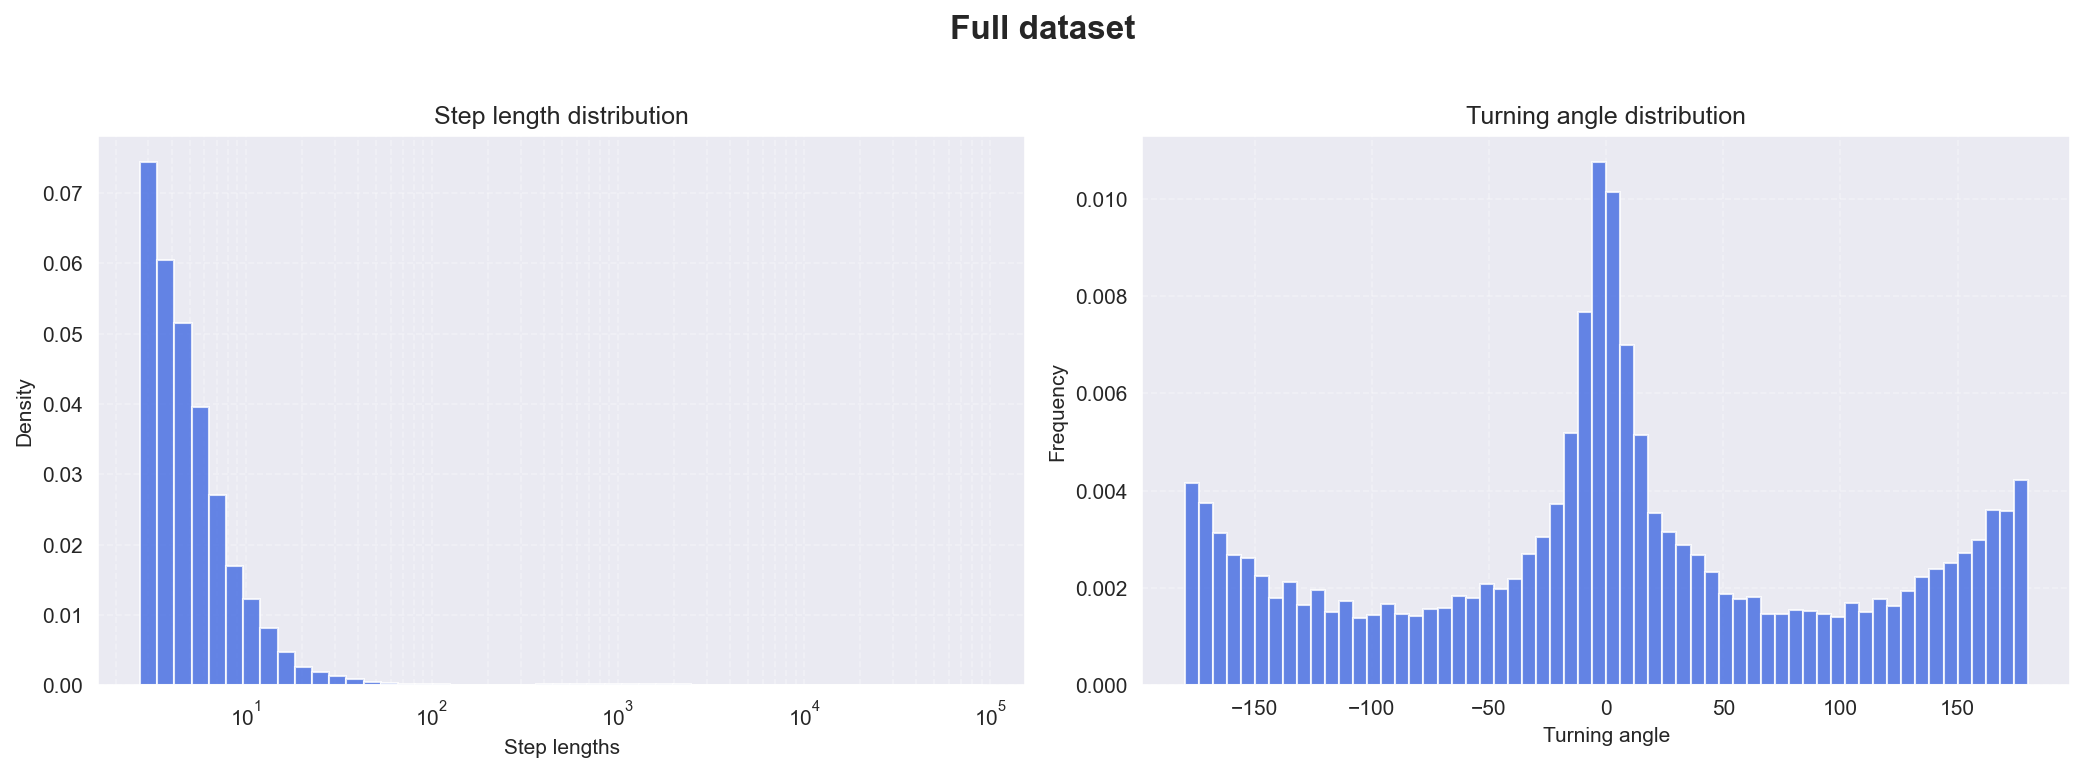

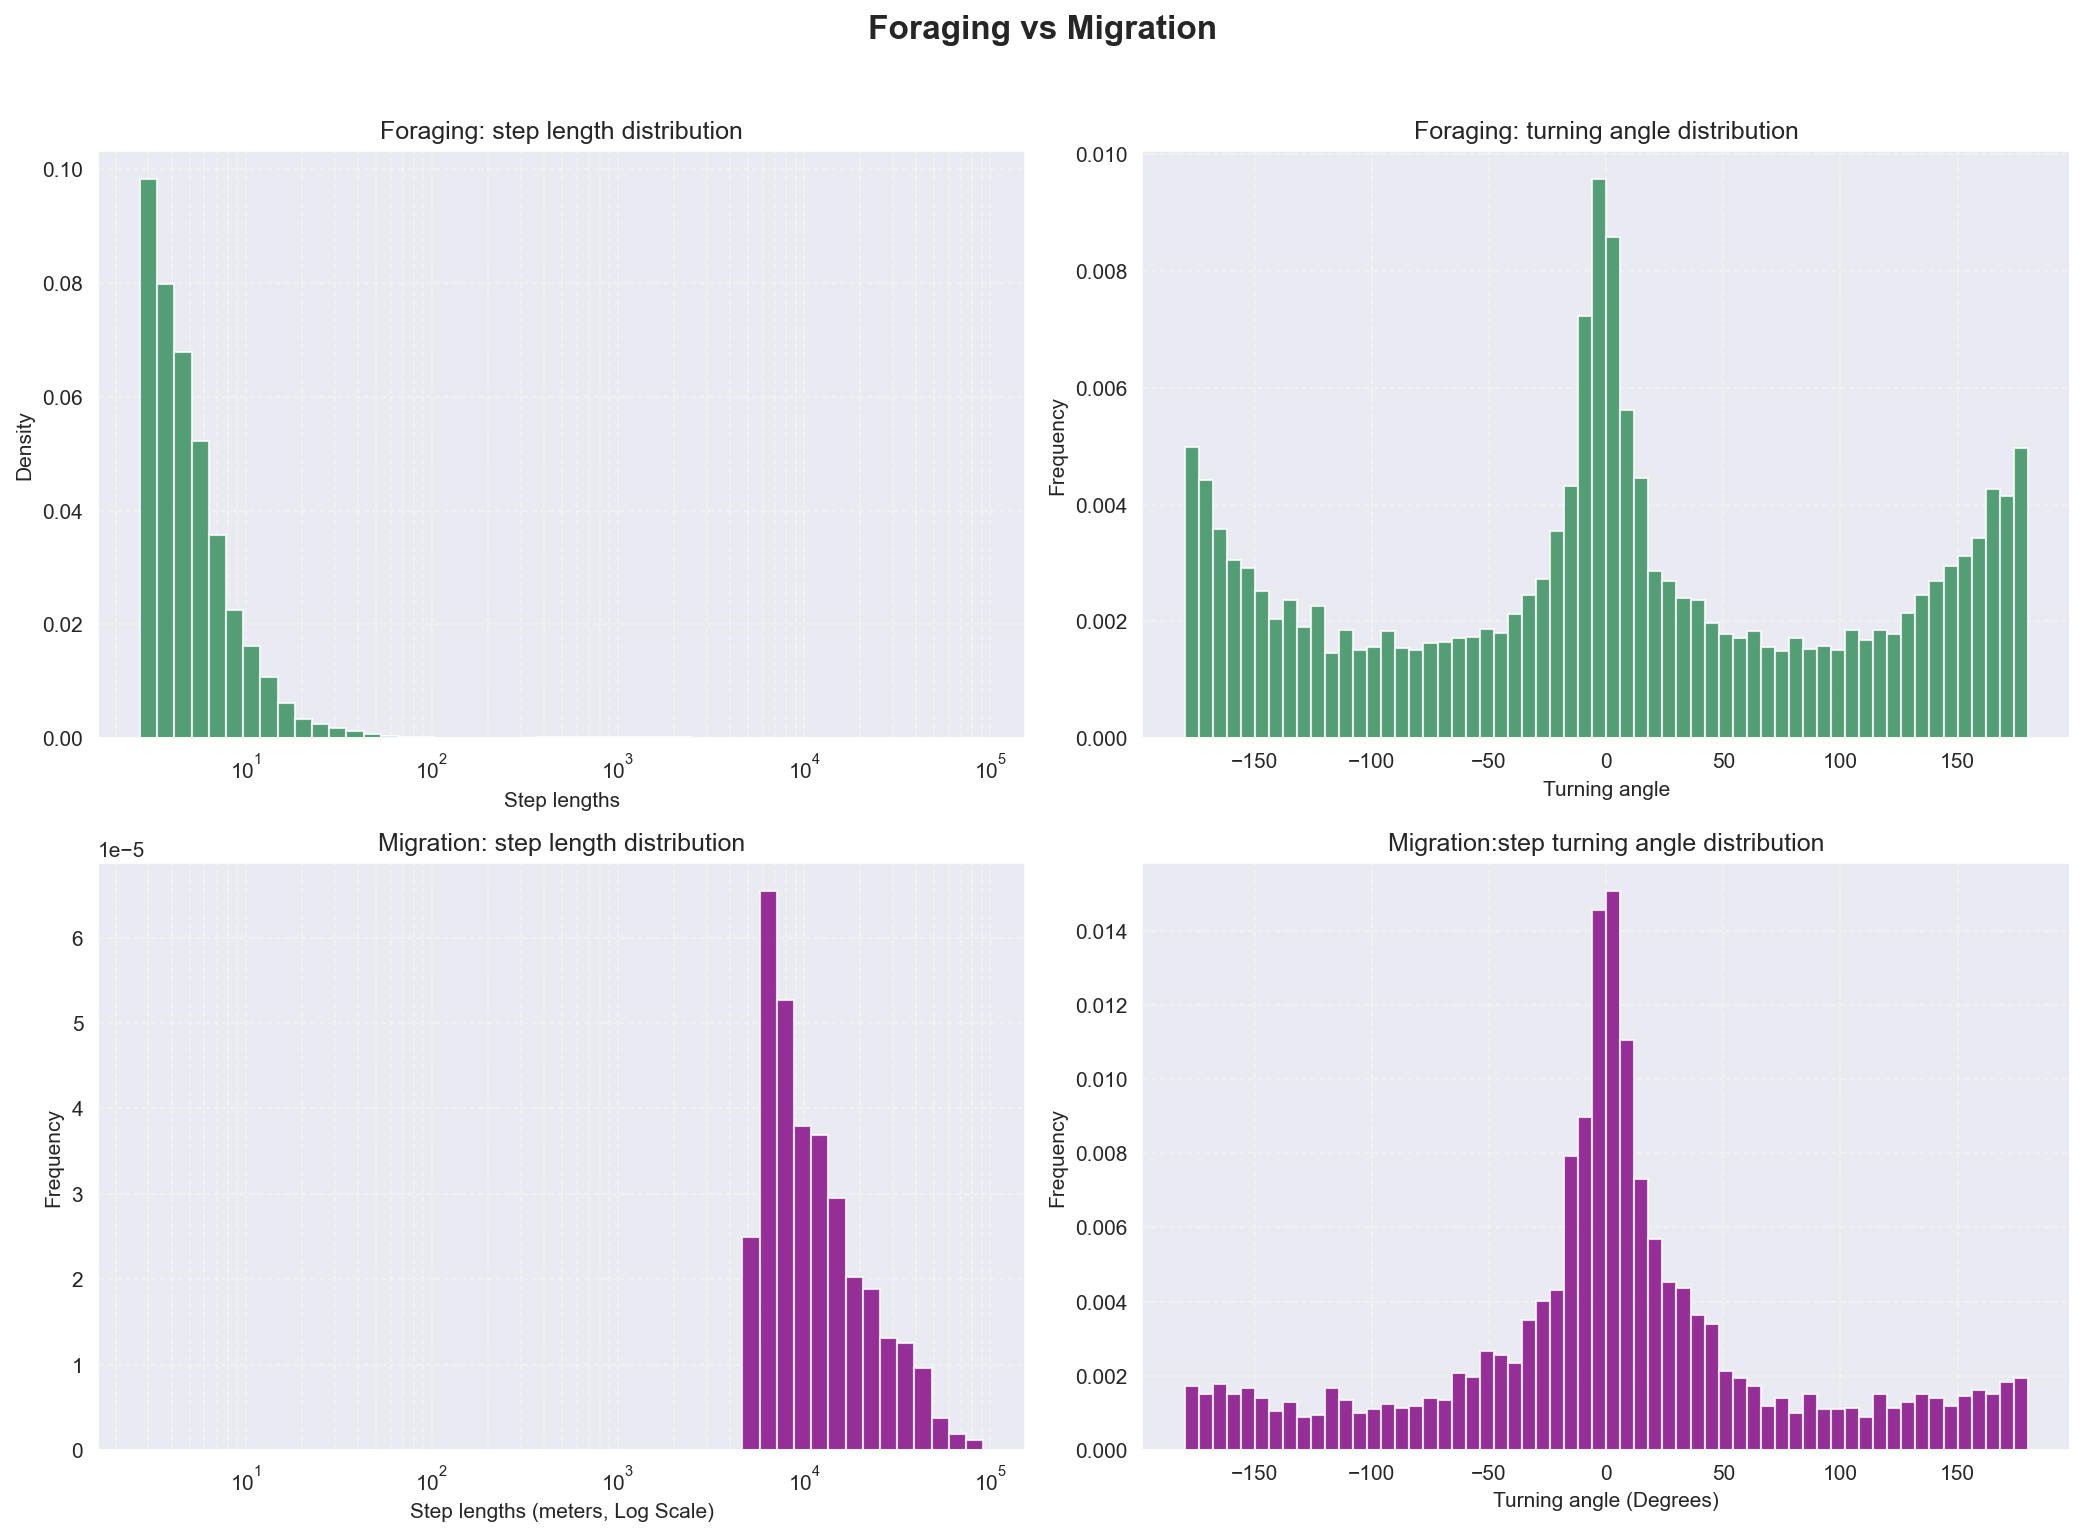

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def haversine_vec(lat1, lon1, lat2, lon2):
    R = 6371000.0 # Earth radius in meters
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

def bearing_vec(lat1, lon1, lat2, lon2):
    la1, lo1, la2, lo2 = map(np.radians, [lat1, lon1, lat2, lon2])
    x = np.sin(lo2-lo1)*np.cos(la2)
    y = np.cos(la1)*np.sin(la2) - np.sin(la1)*np.cos(la2)*np.cos(lo2-lo1)
    return np.degrees(np.arctan2(x, y)) % 360

df_albatrosses['timestamp'] = pd.to_datetime(df_albatrosses['timestamp'], format='ISO8601')

df_time = df_albatrosses.set_index('timestamp')

df_resampled = df_time.groupby('individual_id').resample('15min').first().dropna(subset=['lat', 'lon']).reset_index()

df_resampled = df_resampled.sort_values(by=['individual_id', 'timestamp']).reset_index(drop=True)

df_resampled['dt_sec'] = df_resampled.groupby('individual_id')['timestamp'].diff().dt.total_seconds()

df_resampled['next_lat'] = df_resampled.groupby('individual_id')['lat'].shift(-1)
df_resampled['next_lon'] = df_resampled.groupby('individual_id')['lon'].shift(-1)
df_resampled['prev_lat'] = df_resampled.groupby('individual_id')['lat'].shift(1)
df_resampled['prev_lon'] = df_resampled.groupby('individual_id')['lon'].shift(1)

df_resampled['step_m'] = haversine_vec(df_resampled['lat'], df_resampled['lon'], df_resampled['next_lat'], df_resampled['next_lon'])
df_resampled['speed_ms'] = df_resampled['step_m'] / df_resampled['dt_sec'].shift(-1) # Speed to next point

b_in = bearing_vec(df_resampled['prev_lat'], df_resampled['prev_lon'], df_resampled['lat'], df_resampled['lon'])
b_out = bearing_vec(df_resampled['lat'], df_resampled['lon'], df_resampled['next_lat'], df_resampled['next_lon'])
df_resampled['turn_angle'] = ((b_out - b_in) + 180) % 360 - 180
df_resampled = df_resampled.drop(columns=['next_lat', 'next_lon', 'prev_lat', 'prev_lon'])

MIN_SPEED = 0.0005  
MAX_SPEED = 30.0  
MIN_TIME_GAP = 5400.0
MAX_TIME_GAP = 7200.0

df_clean_for_mig = df_resampled.dropna(subset=['step_m', 'speed_ms', 'turn_angle', 'dt_sec']).copy()
#we shift dt_sec back 1 so we filter the time gap corresponding to the step
df_clean_for_mig['dt_sec_next'] = df_clean_for_mig.groupby('individual_id')['dt_sec'].shift(-1)

df_clean_for_mig = df_clean_for_mig[
    (df_clean_for_mig['speed_ms'] >= MIN_SPEED) & 
    (df_clean_for_mig['speed_ms'] <= MAX_SPEED) &
    (df_clean_for_mig['dt_sec_next'] >= MIN_TIME_GAP) & 
    (df_clean_for_mig['dt_sec_next'] <= MAX_TIME_GAP)
].copy()

# BEHAVIORAL SPLITTING 
# Threshold for storks: >1 m/s (3.6 km/h) is active flight, below is localized foraging
MODE_THRESHOLD = 1.0  

df_foraging = df_clean_for_mig[df_clean_for_mig['speed_ms'] <= MODE_THRESHOLD].copy()
df_migration = df_clean_for_mig[df_clean_for_mig['speed_ms'] > MODE_THRESHOLD].copy()

print(f"\n[Dataset Summaries]")
print(f"Total steps retained: {len(df_clean_for_mig):,}")


fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle("Full dataset", fontweight="bold", fontsize=16, y=1.02)

bins_step = np.logspace(np.log10(max(1, df_clean_for_mig['step_m'].min())), np.log10(df_clean_for_mig['step_m'].max()), 50)

axes[0].hist(df_clean_for_mig['step_m'], bins=bins_step, alpha=0.8, color='royalblue', edgecolor='white', density=True)
axes[0].set_xscale('log')
axes[0].set_xlabel('Step lengths')
axes[0].set_ylabel('Density')
axes[0].set_title('Step length distribution')
axes[0].grid(True, which="both", ls="--", alpha=0.3)

axes[1].hist(df_clean_for_mig['turn_angle'], bins=60, alpha=0.8, color='royalblue', edgecolor='white', density=True)
axes[1].set_xlabel('Turning angle')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Turning angle distribution')
axes[1].grid(True, ls="--", alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Foraging vs Migration", fontweight="bold", fontsize=16, y=1.02)

bins_step = np.logspace(np.log10(max(1, df_clean_for_mig['step_m'].min())), np.log10(df_clean_for_mig['step_m'].max()), 50)

axes[0, 0].hist(df_foraging['step_m'], bins=bins_step, alpha=0.8, color='seagreen', edgecolor='white', density=True)
axes[0, 0].set_xscale('log')
axes[0, 0].set_xlabel('Step lengths')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title('Foraging: step length distribution')
axes[0, 0].grid(True, which="both", ls="--", alpha=0.3)

axes[0, 1].hist(df_foraging['turn_angle'], bins=60, alpha=0.8, color='seagreen', edgecolor='white', density=True)
axes[0, 1].set_xlabel('Turning angle')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Foraging: turning angle distribution')
axes[0, 1].grid(True, ls="--", alpha=0.3)


axes[1, 0].hist(df_migration['step_m'], bins=bins_step, alpha=0.8, color='purple', edgecolor='white', density = True)
axes[1, 0].set_xscale('log')
axes[1, 0].set_xlabel('Step lengths (meters, Log Scale)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Migration: step length distribution')
axes[1, 0].grid(True, which="both", ls="--", alpha=0.3)

axes[1, 1].hist(df_migration['turn_angle'], bins=60, alpha=0.8, color='purple', edgecolor='white', density=True)
axes[1, 1].set_xlabel('Turning angle (Degrees)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Migration:step turning angle distribution')
axes[1, 1].grid(True, ls="--", alpha=0.3)

plt.tight_layout()
plt.show()

The turning angle distributions look different for 2 modes of movement:
* **Foraging:** During slow movements, the bird turns constantly to cover a localized patch of resources.
* **Migration:** During high-speed movement we observe high directional persistance.

Now, we will fit and test stable distribution to the resampled observations for full dataset as well as foraging and migration mode separately.

In [ ]:
import os
import io
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.stats import levy_stable
import stabpy
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)


behavioral_modes = {
    "Full": df_clean_for_mig,
    "Migration": df_migration,
    "Foraging": df_foraging
}

final_results = {}
MC_ITERATIONS = 500 

for mode_name, df_mode in behavioral_modes.items():
    print("=" * 85)
    print(mode_name)
    base_folder = f"stable_plots_resampled/{mode_name.lower()}"
    os.makedirs(f"{base_folder}/passed", exist_ok=True)
    os.makedirs(f"{base_folder}/failed", exist_ok=True)


    bird_counts = df_mode.groupby("individual_id").size()
    print(f"bird counts from {bird_counts.min()} to {bird_counts.max()}")
    filtered_birds = bird_counts[bird_counts >= 500].sort_values(ascending=False).index.tolist()

    print("=" * 85)
    print(f"{len(filtered_birds)} birds")
    print("=" * 85)

    all_birds_database = {}
    MC_ITERATIONS = 500 

    for rank, bird_id in enumerate(filtered_birds):

        df_bird_full = df_mode[df_mode["individual_id"] == bird_id].sort_values("timestamp")
        s_b = df_bird_full["step_m"].values
        total_obs = len(s_b)
        
        try:
            aq, sq, bq, mq = stabpy.stabcull(s_b)
        except Exception:
            aq, sq, bq, mq = 0, 0, 0, 0

        try:
            ar, sr, br, mr = stabpy.stabreg(s_b)
        except Exception:
            ar, sr, br, mr = None, None, None, None
            
        if ar is None:
            print(f"'{bird_id}' failed regression")
            continue  
        print("Estimated for full data", ar, sr, br, mr)
            

        test_res = custom_stabtest(s_b, ilp=MC_ITERATIONS)

        pvals = test_res[9:14]
        passing_tests_count = np.sum(pvals >= 0.05)
        
        safe_bird_name = str(bird_id).replace(" ", "_").replace("(", "").replace(")", "").replace("/", "_")
        
        if passing_tests_count >= 3:
            status_folder = "passed"
            print(f"'{bird_id}' passed validation ({passing_tests_count}/5 tests accepted).")
        else:
            status_folder = "failed"
            print(f"'{bird_id}' failed validation ({passing_tests_count}/5 tests accepted).")
            
        # Save the FULL DATASET parameters to your database
        all_birds_database[bird_id] = {
            "Total Observations (n)": total_obs,
            "Passing Tests Count": passing_tests_count,
            "Status": "Passed" if passing_tests_count >= 3 else "Failed",
            "alpha_cull": aq, "beta_cull": bq, "sigma_cull": sq, "mu_cull": mq,
            "alpha_reg": ar, "beta_reg": br, "sigma_reg": sr, "mu_reg": mr,
            "p_KS": pvals[0], "p_Kuiper": pvals[1], "p_CvM": pvals[2], "p_Watson": pvals[3], "p_AD": pvals[4],
            "stat_KS": test_res[4], "stat_Kuiper": test_res[5], "stat_CvM": test_res[6], "stat_Watson": test_res[7], "stat_AD": test_res[8]
        }

        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        fig.suptitle(f"{bird_id}", fontweight="bold", fontsize=14)
        
        ax1 = axes[0, 0]
        bins = np.logspace(np.log10(max(1, s_b.min())), np.log10(s_b.max()), 50)
        
        ax1.hist(s_b, bins=bins, density=True, alpha=0.5, color="royalblue", edgecolor="white", label="Empirical steps (Full)")
        
        levy_stable.parameterization = 'S0'
        x_grid = np.logspace(np.log10(max(1, s_b.min())), np.log10(s_b.max()), 300)
        
        pdf_fitted = levy_stable.pdf(x_grid, ar, br, loc=mr, scale=sr)
        
        ax1.plot(x_grid, pdf_fitted, color="darkorange", lw=2.5, label=f"Fitted PDF ($\\alpha$={ar:.2f})")
        ax1.set_xscale("log")
        ax1.set_xlabel("Step lengths (meters)")
        ax1.set_ylabel("Probability density")
        ax1.set_title('Histogram with PDF')
        ax1.grid(True, which="both", ls="--", alpha=0.3)
        ax1.legend()

        ax2 = axes[0, 1]
        s_b_sorted = np.sort(s_b)
        theoretical_cdf = stabpy.stabcdf(s_b_sorted, ar, sr, br, mr)
        empirical_cdf = np.arange(1, len(s_b)+1) / (len(s_b)+1)
        sample_indices = np.linspace(0, len(s_b)-1, min(1000, len(s_b))).astype(int)
        
        ax2.scatter(theoretical_cdf[sample_indices], empirical_cdf[sample_indices], 
                    color="crimson", alpha=0.5, s=8, label="empirical quantiles", zorder=3)
        ax2.plot([0, 1], [0, 1], 'k--', label='theoretical fit', lw=1.5, zorder=2)
        ax2.set_xlabel('Theoretical quantiles')
        ax2.set_ylabel('Empirical quantiles')
        ax2.set_title('Q-Q Plot')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        ax3 = axes[1, 0]
        ax3.plot(s_b[:500], color="teal", linewidth=1.0, alpha=0.8)
        ax3.set_xlabel('($t$)')
        ax3.set_ylabel('Step (m)')
        ax3.set_title('First 500 steps')
        ax3.grid(True, alpha=0.3)
        
        ax4 = axes[1, 1]
        params_quant = [aq, bq]
        params_reg = [ar, br]
        x_pos = np.arange(2)
        width = 0.35
        ax4.bar(x_pos - width/2, params_quant, width, label='Quantile (stabcull)', color="orange", alpha=0.8)
        ax4.bar(x_pos + width/2, params_reg, width, label='Regression (stabreg)', color="purple", alpha=0.8)
        ax4.set_xticks(x_pos)
        ax4.set_xticklabels(['$\\alpha$', '$\\beta$'])
        ax4.set_title('Parameter estimation comparison')
        ax4.legend()
        ax4.grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        dashboard_destination = os.path.join(base_folder, status_folder, f"dashboard_{safe_bird_name}.png")
        plt.savefig(dashboard_destination, dpi=150, bbox_inches='tight')
        plt.close()


    per_bird_df3 = pd.DataFrame(all_birds_database).T

    column_ordering = [
        "Total Observations (n)", "Passing Tests Count", "Status",
        "alpha_cull", "beta_cull", "sigma_cull", "mu_cull",
        "alpha_reg", "beta_reg", "sigma_reg", "mu_reg",
        "p_KS", "p_Kuiper", "p_CvM", "p_Watson", "p_AD",
        "stat_KS", "stat_Kuiper", "stat_CvM", "stat_Watson", "stat_AD"
    ]
    per_bird_df3 = per_bird_df3.reindex(columns=column_ordering)


    display(per_bird_df3.round(4))

Full
bird counts from 7 to 1938
12 birds
Estimated for full data 0.27405208678032983 23.920472528758037 1.0 -4784.955403324535

 Stabtest fitted params Alpha=0.2741, Sigma=23.9205, Beta=1.0000, Mu=-4784.9554


100%|██████████| 500/500 [02:28<00:00,  3.37it/s]


'unbanded-159' failed validation (1/5 tests accepted).
Estimated for full data 0.2878327069670186 2341.415410885187 1.0 -561.8564392185408

 Stabtest fitted params Alpha=0.2878, Sigma=2341.4154, Beta=1.0000, Mu=-561.8564


100%|██████████| 500/500 [01:39<00:00,  5.03it/s]


'1163-1163' passed validation (5/5 tests accepted).
Estimated for full data 0.28376537981106587 15.286823659406855 1.0 19874.02214181607

 Stabtest fitted params Alpha=0.2838, Sigma=15.2868, Beta=1.0000, Mu=19874.0221


...

100%|██████████| 500/500 [00:32<00:00, 15.21it/s]


'4266-84831108' passed validation (5/5 tests accepted).
Estimated for full data 1.021220758113089 432.6991322264826 1.0 28946.17040363493

 Stabtest fitted params Alpha=1.0212, Sigma=432.6991, Beta=1.0000, Mu=28946.1704


100%|██████████| 500/500 [00:40<00:00, 12.20it/s]


'4261-2228' failed validation (0/5 tests accepted).


,Total Observations (n),Passing Tests Count,Status,alpha_cull,beta_cull,sigma_cull,mu_cull,alpha_reg,beta_reg,sigma_reg,mu_reg,p_KS,p_Kuiper,p_CvM,p_Watson,p_AD,stat_KS,stat_Kuiper,stat_CvM,stat_Watson,stat_AD
unbanded-159,1499,5,Passed,1.381368,1.0,438.024561,518.40286,0.121752,-1.0,82.79531,8718.014368,0.734,0.224,0.734,0.202,0.732,21.270386,37.422008,130.945916,120.942085,602.990885
unbanded-156,997,5,Passed,1.472242,1.0,605.51166,511.467318,0.120326,-1.0,126.528255,15095.610142,0.724,0.202,0.72,0.204,0.716,18.088497,31.200002,88.616157,81.356009,407.144457
unbanded-153,989,4,Passed,1.299017,1.0,385.983066,735.555312,0.1366,1.0,385.983066,735.555312,0.568,0.616,0.436,1.0,0.0,22.697268,22.725402,175.374644,32.053249,inf
1163-1163,879,0,Failed,2.0,1.0,1395.364779,1505.007807,2.0,-1.0,1107.311404,1690.545539,0.0,0.0,0.0,0.0,0.0,4.630179,8.824349,3.618558,3.090414,25.708331
3275-30662,743,0,Failed,2.0,1.0,1256.013938,1527.624421,2.0,-1.0,1052.638555,1755.593658,0.0,0.0,0.0,0.0,0.0,3.27044,6.409757,2.036618,1.595954,15.180155
unbanded-154,724,0,Failed,2.0,1.0,1017.0095,887.962512,1.551991,1.0,683.631188,1905.959741,0.0,0.0,0.0,0.0,0.012,8.421101,9.388802,22.832433,7.544293,178.892051
4266-84831108,686,5,Passed,2.0,1.0,1053.060318,654.442412,1.460353,1.0,655.898491,2345.434466,0.064,0.064,0.064,0.064,0.098,11.187414,11.380554,44.643709,12.845276,522.900941
4261-2228,581,0,Failed,2.0,1.0,1056.693922,564.977453,1.021221,1.0,432.699132,28946.170404,0.0,0.0,0.0,0.0,0.0,24.228505,24.268898,193.999312,48.483161,inf


## 3. Turning angle analysis


### Dependance with lengths

In [ ]:
def empirical_angle_dependence(bird_ids, df_mode, mode_name):
    for bird_id in bird_ids:

        df_bird = df_mode[df_mode['individual_id'] == bird_id].dropna(subset=['step_m', 'turn_angle']).copy()
        if len(df_bird) < 100:
            return
            
        steps = df_bird['step_m'].values
        angles = df_bird['turn_angle'].values
        
        bins = np.arange(-180, 181, 30)
        bin_centers = (bins[:-1] + bins[1:]) / 2
        
        # we use median instead of mean because heavy tails skew the mean heavily
        median_steps = []
        for i in range(len(bins)-1):
            mask = (angles >= bins[i]) & (angles < bins[i+1])
            if np.any(mask):
                median_steps.append(np.median(steps[mask]))
            else:
                median_steps.append(np.nan)
                
        fig, ax = plt.subplots(figsize=(10, 6))
        
        ax.scatter(angles, steps, alpha=0.5, color='royalblue', s=10, label='step lengths')
        
        ax.plot(bin_centers, median_steps, 'crimson', marker='o', lw=3, markersize=8, label='median step length')
        
        ax.set_yscale('log')
        ax.set_xlim(-180, 180)
        ax.set_xticks(np.arange(-180, 181, 45))
        ax.set_xlabel('Turning angle')
        ax.set_ylabel('Step length')
        ax.set_title(f'Step-Angle {bird_id} ({mode_name})')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        ax.axvline(0, color='black', linestyle='--', alpha=0.5)
        
        plt.show()

empirical_angle_dependence(["unbounded-159", "1163-1163"], df_clean_for_mig, "full dataset")
empirical_angle_dependence(["unbounded-159", "1163-1163"], df_foraging, "foraging")

Total Pooled Observations: 13,173


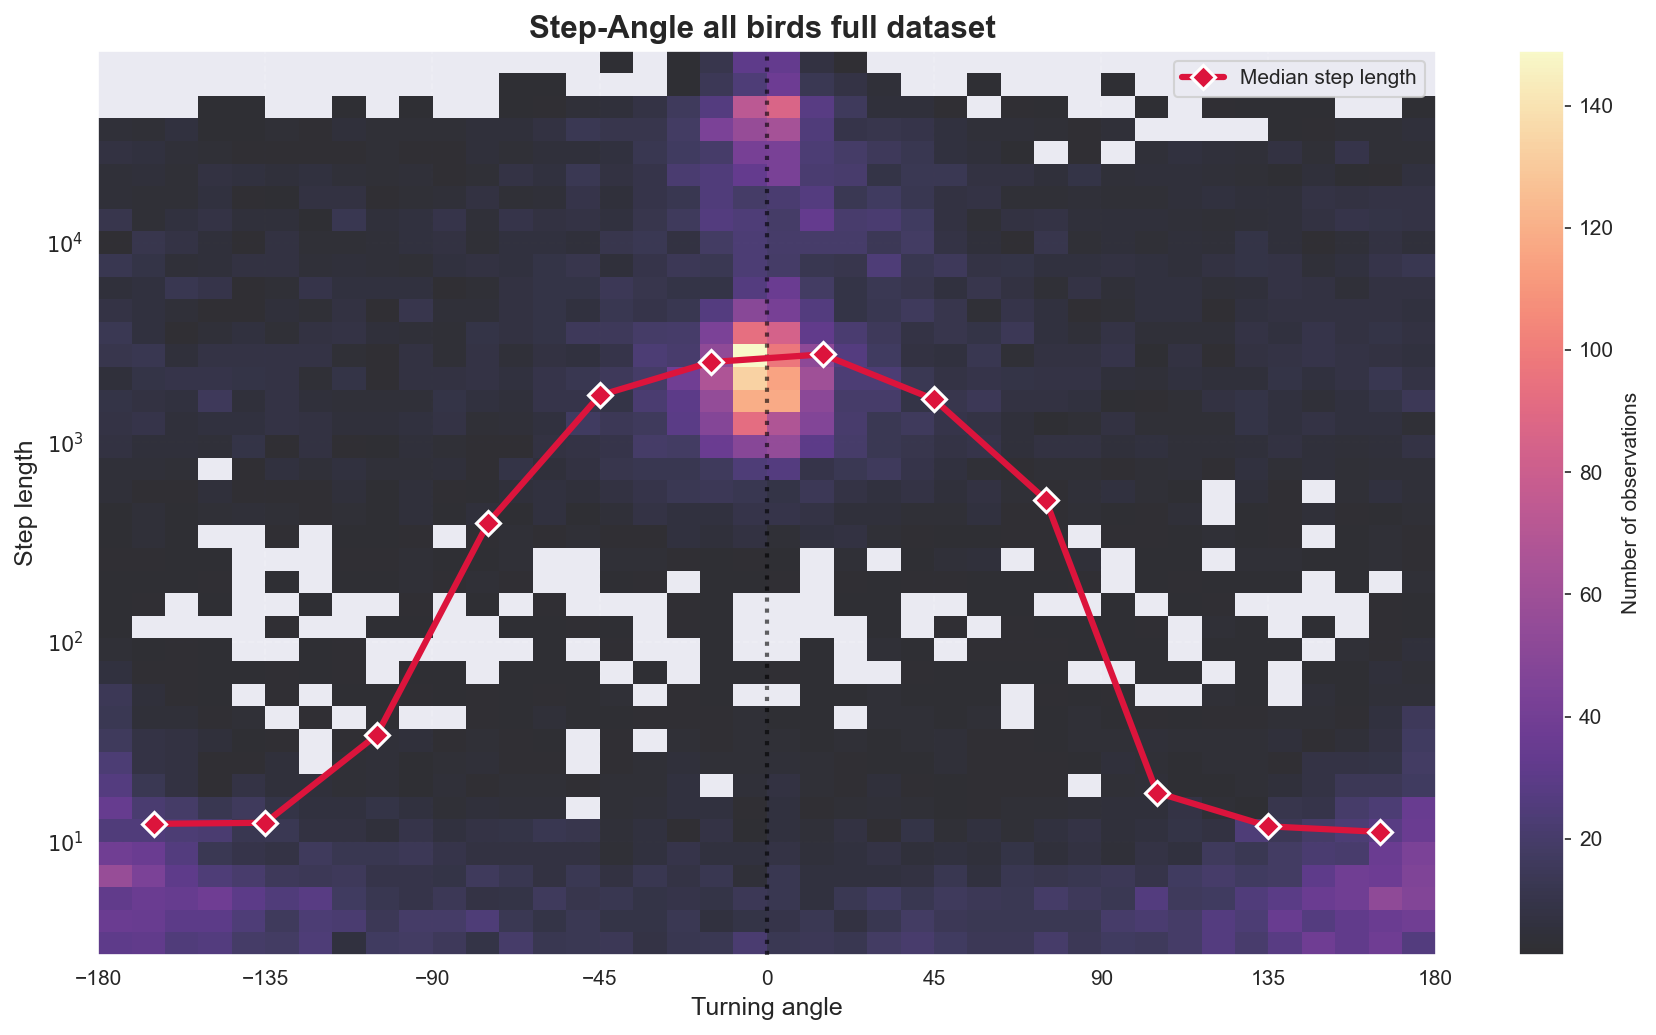

Total Pooled Observations: 9,975


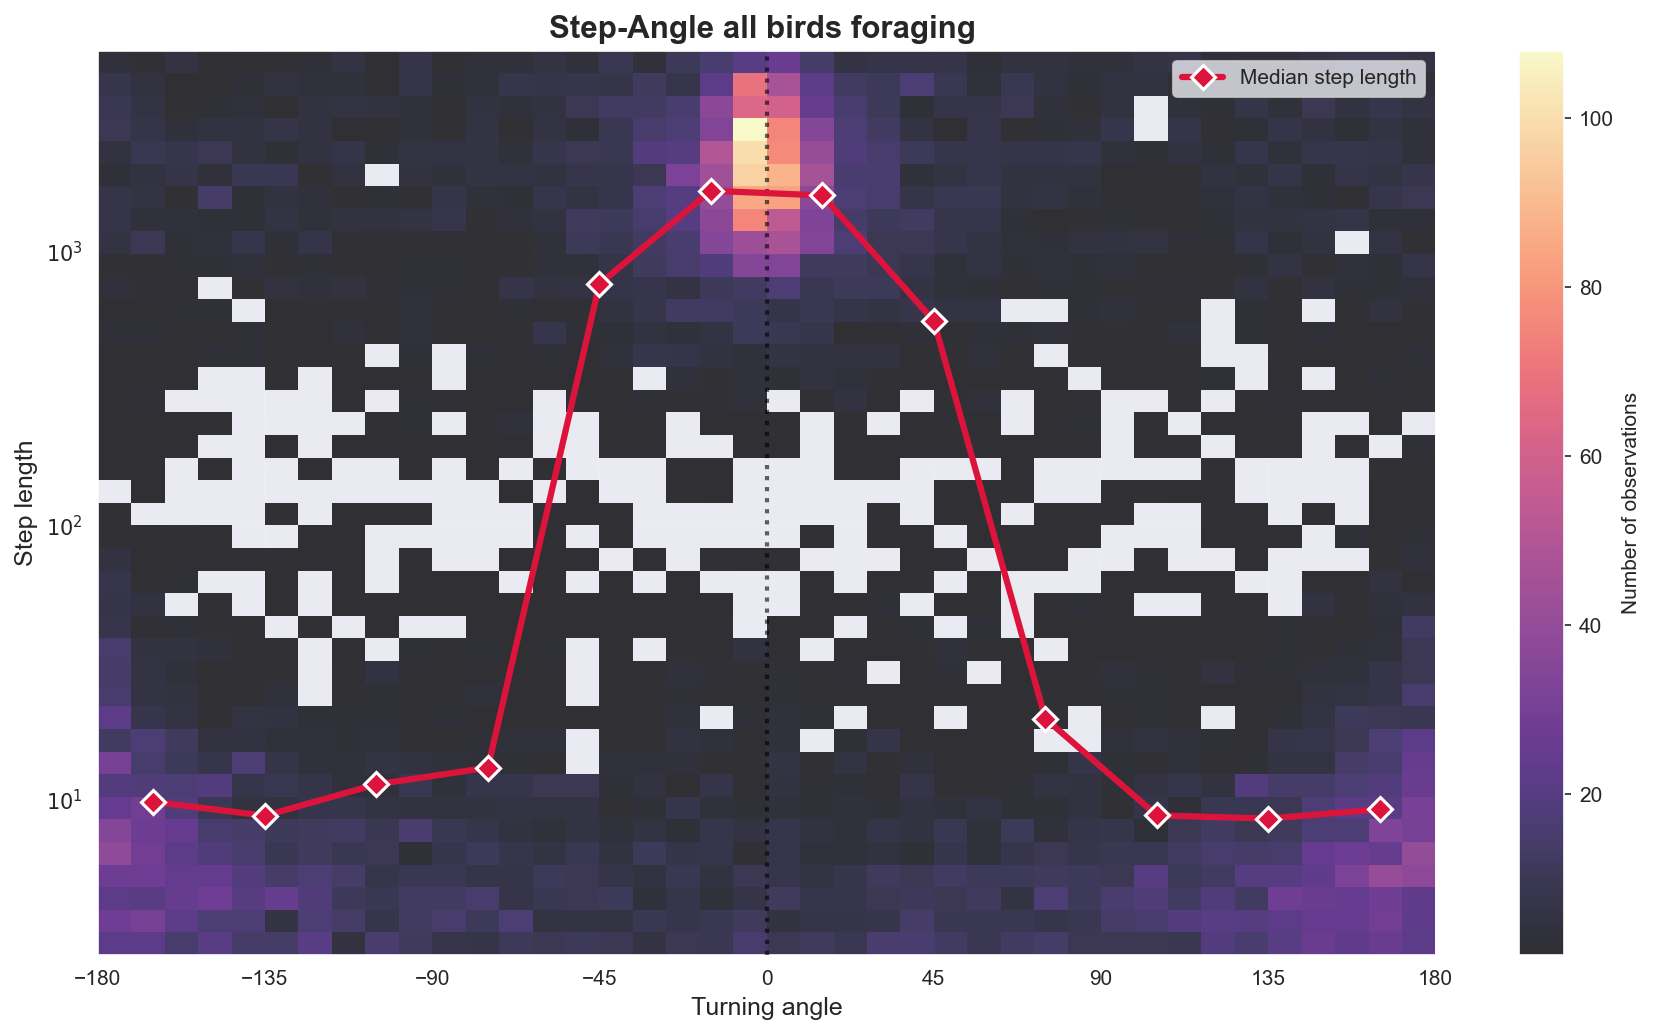

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # We will use seaborn for the beautiful KDE plots!

def pooled_empirical_angle_dependence(df_mode, mode_name):

    df_pooled = df_mode.dropna(subset=['step_m', 'turn_angle']).copy()
    
    total_obs = len(df_pooled)
        
    print(f"Total Pooled Observations: {total_obs:,}")
    
    steps = df_pooled['step_m'].values
    angles = df_pooled['turn_angle'].values
    
    bins = np.arange(-180, 181, 30)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    median_steps = []
    
    for i in range(len(bins)-1):
        mask = (angles >= bins[i]) & (angles < bins[i+1])
        if np.any(mask):
            median_steps.append(np.median(steps[mask]))
        else:
            median_steps.append(np.nan)
            
    fig, ax = plt.subplots(figsize=(12, 7))
    
    log_steps = np.log10(steps)
        
    h = ax.hist2d(angles, log_steps, bins=[40, 40], cmap='magma', cmin=1, alpha=0.8)
    fig.colorbar(h[3], ax=ax, label='Number of observations')
    if mode_name=="full dataset":
        ax.set_yticks([1, 2, 3, 4])
        ax.set_yticklabels([f"$10^{i}$" for i in range(1,5)])
    else:
        ax.set_yticks([1, 2, 3])
        ax.set_yticklabels([f"$10^{i}$" for i in range(1,4)])
    

    median_plot = np.log10(median_steps)        
    ax.plot(bin_centers, median_plot, 'crimson', marker='D', lw=3, markersize=8, 
            markeredgecolor='white', markeredgewidth=1.5, label='Median step length', zorder=5)
    
    ax.set_xlim(-180, 180)
    ax.set_xticks(np.arange(-180, 181, 45))
    ax.set_xlabel('Turning angle', fontsize=12)
    ax.set_ylabel('Step length', fontsize=12)
    ax.set_title(f'Step-Angle all birds {mode_name} ', fontsize=15, fontweight='bold')
    
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.2, linestyle='--')
    
    ax.axvline(0, color='black', linestyle=':', lw=2, alpha=0.6, zorder=4)
    
    plt.tight_layout()
    plt.show()

pooled_empirical_angle_dependence( df_clean_for_mig, "full dataset")

pooled_empirical_angle_dependence( df_foraging, "foraging")

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, kruskal

def verify_statistical_dependence(df_mode, mode_name, bird_id=None):
    print("="*20)
    print(mode_name)

    if bird_id:
        print("bird:", bird_id)
        df_pooled = df_mode[df_mode["individual_id"] == bird_id].dropna(subset=['step_m', 'turn_angle']).copy()
    else:
        df_pooled = df_mode.dropna(subset=['step_m', 'turn_angle']).copy()
    
    steps = df_pooled['step_m'].values
    angles = df_pooled['turn_angle'].values
    
    # We take the absolute angle (deviation from 0) 
    # Hypothesis: as absolute angle increases, step length decreases (Negative correlation)
    abs_angles = np.abs(angles)
    rho, p_val_spearman = spearmanr(abs_angles, steps, alternative="less")
    
    print("\n1. Spearman Rank Correlation (Absolute angle vs step)")
    print(f"Spearman's rho : {rho:.4f}")
    print(f"p-value: {p_val_spearman:.4f}")
        
    if rho < 0:
        print("Confirmed. As the albatros turns sharper, its steps get shorter.")
        
    # 2. Kruskal-Wallis H-Test (Non-parametric ANOVA across bins)
    # Hypothesis: The median step lengths across our 30-degree bins are not equal.
    bins = np.arange(-180, 181, 30)
    binned_steps = []
    
    for i in range(len(bins)-1):
        mask = (angles >= bins[i]) & (angles < bins[i+1])
        if np.sum(mask) > 10: # only test bins with enough data
            binned_steps.append(steps[mask])
            
    stat_kw, p_val_kw = kruskal(*binned_steps)
    
    print("\n2. Kruskal-Wallis H-Test (Comparing medians across 30deg bins)")
    print(f"H-statistic: {stat_kw:.2f}")
    print(f"p-value: {p_val_kw:.4f}")
        
    print("Confirmed. The step length distribution changes depending on the bird's heading.")

top_birds = ["unbounded-159", "1163-1163", "unbounded-156", "unbanded-153"]
verify_statistical_dependence(df_clean_for_mig, "Full dataset")
#verify_statistical_dependence(df_clean_for_mig, "Full dataset", top_birds[0])

verify_statistical_dependence(df_foraging, "Foraging")
#verify_statistical_dependence(df_foraging, "Foraging", top_birds[0])

Full dataset

1. Spearman Rank Correlation (Absolute angle vs step)
Spearman's rho : -0.4356
p-value: 0.0000
Confirmed. As the albatros turns sharper, its steps get shorter.

2. Kruskal-Wallis H-Test (Comparing medians across 30deg bins)
H-statistic: 2561.02
p-value: 0.0000
Confirmed. The step length distribution changes depending on the bird's heading.
Foraging

1. Spearman Rank Correlation (Absolute angle vs step)
Spearman's rho : -0.4479
p-value: 0.0000
Confirmed. As the albatros turns sharper, its steps get shorter.

2. Kruskal-Wallis H-Test (Comparing medians across 30deg bins)
H-statistic: 2174.12
p-value: 0.0000
Confirmed. The step length distribution changes depending on the bird's heading.


The correlation analysis reveals a clear structural dependency between movement parameters in the albatross dataset.

Standard theoretical random walk models, including pure 2D Lévy flights, operate under the assumption of isotropy: step lengths ($L$) and turning angles ($\theta$) are assumed to be independent random variables. However, both the full dataset and the isolated foraging subset demonstrate a strong negative correlation between these variables (Spearman's rank correlation: $\rho = -0.4356$ for the full dataset and $\rho = -0.4479$ for foraging, both with $p < 0.0001$).

This negative correlation is visually confirmed by the smoothed density heatmaps and the overlaid median trajectories, which show a distinct "tent-like" shape. The data clearly indicates that as an albatross makes sharper turns (angles deviating further from $0^\circ$), its corresponding step lengths become significantly shorter. Conversely, long-distance steps are almost exclusively associated with forward-directed movement (turning angles near $0^\circ$). This angular dependence of the step length distribution is further corroborated by the Kruskal-Wallis H-test ($p < 0.0001$), confirming significant differences in median step lengths across $30^\circ$ directional bins.

Because the generation of heavy-tailed spatial steps is conditionally dependent on directional persistence, we must reject the isotropic Lévy flight hypothesis for this dataset. To accurately model albatross movement—whether during general flight or specific foraging behavior—the framework must inherently integrate this correlation, likely through a Correlated Random Walk (CRW) model or a state-space approach that couples turning dynamics with step length generation.